In [1]:
# ============================================================
# EXERCISE 8.4 - ADVERSARIAL MACHINE LEARNING
# CELL 1 - SETUP AND PATH CONFIGURATION
# ============================================================

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image

from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms


# ============================================================
# HEADER
# ============================================================

print("=" * 70)
print("EXERCISE 8.4 - ADVERSARIAL EXAMPLES / FGSM")
print("=" * 70)


# ============================================================
# RANDOM SEED
# ============================================================

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\n" + "-" * 70)
print("DEVICE")
print("-" * 70)

print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "CUDA version:",
        torch.version.cuda
    )


# ============================================================
# BASE PATH
# ============================================================

BASE_PATH = r"E:\ML_Safety"

TRAIN_DIR = os.path.join(
    BASE_PATH,
    "train"
)

TEST_DIR = os.path.join(
    BASE_PATH,
    "test"
)

FOG_DIR = os.path.join(
    BASE_PATH,
    "test-fog"
)

NIGHT_DIR = os.path.join(
    BASE_PATH,
    "test-night"
)

TOWN_DIR = os.path.join(
    BASE_PATH,
    "test-town-01"
)

MODEL_DIR = os.path.join(
    BASE_PATH,
    "model_outputs"
)

OUTPUT_DIR = os.path.join(
    BASE_PATH,
    "adversarial_results"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# PATH CHECK
# ============================================================

print("\n" + "-" * 70)
print("PATH CONFIGURATION")
print("-" * 70)

print("Base path       :", BASE_PATH)
print("Train directory :", TRAIN_DIR)
print("Test directory  :", TEST_DIR)
print("Fog directory   :", FOG_DIR)
print("Night directory :", NIGHT_DIR)
print("Town directory  :", TOWN_DIR)
print("Model directory :", MODEL_DIR)
print("Output directory:", OUTPUT_DIR)


# ============================================================
# DIRECTORY VERIFICATION
# ============================================================

print("\n" + "-" * 70)
print("DIRECTORY CHECK")
print("-" * 70)

directories = {
    "Train": TRAIN_DIR,
    "Test": TEST_DIR,
    "Fog": FOG_DIR,
    "Night": NIGHT_DIR,
    "Town": TOWN_DIR,
    "Models": MODEL_DIR
}

for name, path in directories.items():

    print(
        f"{name:8s}:",
        "EXISTS" if os.path.exists(path) else "MISSING",
        "->",
        path
    )


# ============================================================
# FGSM CONFIGURATION
# ============================================================

EPSILONS = [
    0.01,
    0.05,
    0.10
]

BATCH_SIZE = 64


print("\n" + "-" * 70)
print("FGSM CONFIGURATION")
print("-" * 70)

print(
    "Attack:",
    "Fast Gradient Sign Method (FGSM)"
)

print(
    "Epsilon values:",
    EPSILONS
)

print(
    "Batch size:",
    BATCH_SIZE
)


# ============================================================
# IMAGE TRANSFORM
# ============================================================

transform = transforms.Compose([
    transforms.Resize(
        (224, 224)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


print("\n" + "-" * 70)
print("IMAGE TRANSFORM")
print("-" * 70)

print(transform)


# ============================================================
# MODEL PATHS
# ============================================================

MODEL_PATHS = {

    "Pedestrian":
        os.path.join(
            MODEL_DIR,
            "best_pedestrian.pth"
        ),

    "Traffic Light":
        os.path.join(
            MODEL_DIR,
            "best_traffic_light.pth"
        ),

    "Vehicle":
        os.path.join(
            MODEL_DIR,
            "best_vehicle.pth"
        )
}


# ============================================================
# MODEL FILE CHECK
# ============================================================

print("\n" + "-" * 70)
print("MODEL FILE CHECK")
print("-" * 70)

for model_name, model_path in MODEL_PATHS.items():

    print(
        f"{model_name:15s}:",
        os.path.exists(model_path),
        "->",
        model_path
    )


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

EXERCISE 8.4 - ADVERSARIAL EXAMPLES / FGSM

----------------------------------------------------------------------
DEVICE
----------------------------------------------------------------------
Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
CUDA version: 12.1

----------------------------------------------------------------------
PATH CONFIGURATION
----------------------------------------------------------------------
Base path       : E:\ML_Safety
Train directory : E:\ML_Safety\train
Test directory  : E:\ML_Safety\test
Fog directory   : E:\ML_Safety\test-fog
Night directory : E:\ML_Safety\test-night
Town directory  : E:\ML_Safety\test-town-01
Model directory : E:\ML_Safety\model_outputs
Output directory: E:\ML_Safety\adversarial_results

----------------------------------------------------------------------
DIRECTORY CHECK
----------------------------------------------------------------------
Train   : EXISTS -> E:\ML_Safety\train
Test    : EXISTS -> E:\ML_Safety\test
Fog     

In [2]:
# ============================================================
# EXERCISE 8.4 - LOADING CARLA MODELS
# CELL 2
# ============================================================

print("=" * 70)
print("EXERCISE 8.4 - LOADING CARLA MODELS")
print("=" * 70)


# ============================================================
# RESNET-18 MODEL LOADER
# ============================================================

def load_carla_model(
    model_path,
    model_name
):

    print("\n" + "-" * 60)
    print(f"Loading {model_name}...")
    print("-" * 60)

    # Create ResNet-18
    model = torchvision.models.resnet18(
        weights=None
    )

    # CARLA binary classification
    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    # Load trained weights
    checkpoint = torch.load(
        model_path,
        map_location=device,
        weights_only=True
    )

    # Handle either a raw state_dict
    # or a checkpoint dictionary.
    if isinstance(
        checkpoint,
        dict
    ) and "state_dict" in checkpoint:

        state_dict = checkpoint[
            "state_dict"
        ]

    else:

        state_dict = checkpoint


    # Remove possible DataParallel prefix
    cleaned_state_dict = {}

    for key, value in state_dict.items():

        new_key = key

        if new_key.startswith(
            "module."
        ):

            new_key = new_key[
                len("module.") :
            ]

        cleaned_state_dict[
            new_key
        ] = value


    model.load_state_dict(
        cleaned_state_dict,
        strict=True
    )

    model = model.to(
        device
    )

    model.eval()

    print(
        "Loaded successfully."
    )

    print(
        "Device:",
        next(
            model.parameters()
        ).device
    )

    print(
        "Evaluation mode:",
        not model.training
    )

    print(
        "Trainable parameters:",
        sum(
            p.numel()
            for p in model.parameters()
        )
    )

    return model


# ============================================================
# LOAD ALL THREE MODELS
# ============================================================

models = {}

for model_name, model_path in MODEL_PATHS.items():

    models[
        model_name
    ] = load_carla_model(
        model_path,
        model_name
    )


# ============================================================
# MODEL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("MODEL SUMMARY")
print("=" * 70)

for model_name, model in models.items():

    parameter_count = sum(
        p.numel()
        for p in model.parameters()
    )

    print(
        f"{model_name:15s} | "
        f"Device: "
        f"{next(model.parameters()).device} | "
        f"Parameters: "
        f"{parameter_count:,}"
    )


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("ALL CARLA MODELS LOADED SUCCESSFULLY")
print("=" * 70)

print("\nCELL 2 COMPLETE")
print("=" * 70)

EXERCISE 8.4 - LOADING CARLA MODELS

------------------------------------------------------------
Loading Pedestrian...
------------------------------------------------------------


RuntimeError: Error(s) in loading state_dict for ResNet:
	Missing key(s) in state_dict: "conv1.weight", "bn1.weight", "bn1.bias", "bn1.running_mean", "bn1.running_var", "layer1.0.conv1.weight", "layer1.0.bn1.weight", "layer1.0.bn1.bias", "layer1.0.bn1.running_mean", "layer1.0.bn1.running_var", "layer1.0.conv2.weight", "layer1.0.bn2.weight", "layer1.0.bn2.bias", "layer1.0.bn2.running_mean", "layer1.0.bn2.running_var", "layer1.1.conv1.weight", "layer1.1.bn1.weight", "layer1.1.bn1.bias", "layer1.1.bn1.running_mean", "layer1.1.bn1.running_var", "layer1.1.conv2.weight", "layer1.1.bn2.weight", "layer1.1.bn2.bias", "layer1.1.bn2.running_mean", "layer1.1.bn2.running_var", "layer2.0.conv1.weight", "layer2.0.bn1.weight", "layer2.0.bn1.bias", "layer2.0.bn1.running_mean", "layer2.0.bn1.running_var", "layer2.0.conv2.weight", "layer2.0.bn2.weight", "layer2.0.bn2.bias", "layer2.0.bn2.running_mean", "layer2.0.bn2.running_var", "layer2.0.downsample.0.weight", "layer2.0.downsample.1.weight", "layer2.0.d

In [3]:
# ============================================================
# EXERCISE 8.4 - LOADING CARLA MODELS
# CELL 2 - CORRECTED CHECKPOINT LOADER
# ============================================================

print("=" * 70)
print("EXERCISE 8.4 - LOADING CARLA MODELS")
print("=" * 70)


# ============================================================
# RESNET-18 MODEL LOADER
# ============================================================

def load_carla_model(model_path, model_name):

    print("\n" + "-" * 60)
    print(f"Loading {model_name}...")
    print("-" * 60)

    # --------------------------------------------------------
    # CREATE RESNET-18
    # --------------------------------------------------------

    model = torchvision.models.resnet18(
        weights=None
    )

    # Binary classifier:
    # class 0 = absent
    # class 1 = present
    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    # --------------------------------------------------------
    # LOAD CHECKPOINT
    # --------------------------------------------------------

    checkpoint = torch.load(
        model_path,
        map_location=device,
        weights_only=True
    )

    print(
        "Checkpoint type:",
        type(checkpoint)
    )

    # --------------------------------------------------------
    # EXTRACT ACTUAL MODEL WEIGHTS
    # --------------------------------------------------------

    if isinstance(checkpoint, dict):

        if "model_state_dict" in checkpoint:

            state_dict = checkpoint[
                "model_state_dict"
            ]

            print(
                "Using checkpoint['model_state_dict']"
            )

        elif "state_dict" in checkpoint:

            state_dict = checkpoint[
                "state_dict"
            ]

            print(
                "Using checkpoint['state_dict']"
            )

        else:

            # In case the checkpoint itself
            # is already a state dictionary.
            state_dict = checkpoint

            print(
                "Using checkpoint directly"
            )

    else:

        raise TypeError(
            "Unsupported checkpoint format: "
            f"{type(checkpoint)}"
        )


    # --------------------------------------------------------
    # REMOVE DataParallel PREFIX IF PRESENT
    # --------------------------------------------------------

    cleaned_state_dict = {}

    for key, value in state_dict.items():

        if key.startswith("module."):

            key = key[
                len("module.") :
            ]

        cleaned_state_dict[
            key
        ] = value


    # --------------------------------------------------------
    # LOAD WEIGHTS
    # --------------------------------------------------------

    missing_keys, unexpected_keys = (
        model.load_state_dict(
            cleaned_state_dict,
            strict=False
        )
    )


    # --------------------------------------------------------
    # VERIFY STATE DICT
    # --------------------------------------------------------

    if len(missing_keys) > 0:

        print(
            "\nWARNING - Missing keys:"
        )

        for key in missing_keys[:10]:
            print(" ", key)

        if len(missing_keys) > 10:
            print(
                f" ... and "
                f"{len(missing_keys) - 10} more"
            )


    if len(unexpected_keys) > 0:

        print(
            "\nWARNING - Unexpected keys:"
        )

        for key in unexpected_keys[:10]:
            print(" ", key)

        if len(unexpected_keys) > 10:
            print(
                f" ... and "
                f"{len(unexpected_keys) - 10} more"
            )


    # --------------------------------------------------------
    # MOVE MODEL TO GPU
    # --------------------------------------------------------

    model = model.to(
        device
    )

    model.eval()


    # --------------------------------------------------------
    # SUMMARY
    # --------------------------------------------------------

    print(
        "\nLoaded successfully."
    )

    print(
        "Device:",
        next(
            model.parameters()
        ).device
    )

    print(
        "Evaluation mode:",
        not model.training
    )

    print(
        "Trainable parameters:",
        sum(
            p.numel()
            for p in model.parameters()
        )
    )

    return model


# ============================================================
# LOAD ALL THREE MODELS
# ============================================================

models = {}

for model_name, model_path in MODEL_PATHS.items():

    models[
        model_name
    ] = load_carla_model(
        model_path,
        model_name
    )


# ============================================================
# MODEL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("MODEL SUMMARY")
print("=" * 70)

for model_name, model in models.items():

    parameter_count = sum(
        p.numel()
        for p in model.parameters()
    )

    print(
        f"{model_name:15s} | "
        f"Device: "
        f"{next(model.parameters()).device} | "
        f"Parameters: "
        f"{parameter_count:,}"
    )


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("ALL CARLA MODELS LOADED SUCCESSFULLY")
print("=" * 70)

print("\nCELL 2 COMPLETE")
print("=" * 70)

EXERCISE 8.4 - LOADING CARLA MODELS

------------------------------------------------------------
Loading Pedestrian...
------------------------------------------------------------
Checkpoint type: <class 'dict'>
Using checkpoint['model_state_dict']

Loaded successfully.
Device: cuda:0
Evaluation mode: True
Trainable parameters: 11177538

------------------------------------------------------------
Loading Traffic Light...
------------------------------------------------------------
Checkpoint type: <class 'dict'>
Using checkpoint['model_state_dict']

Loaded successfully.
Device: cuda:0
Evaluation mode: True
Trainable parameters: 11177538

------------------------------------------------------------
Loading Vehicle...
------------------------------------------------------------
Checkpoint type: <class 'dict'>
Using checkpoint['model_state_dict']

Loaded successfully.
Device: cuda:0
Evaluation mode: True
Trainable parameters: 11177538

MODEL SUMMARY
Pedestrian      | Device: cuda:0 | Pa

In [4]:
# ============================================================
# EXERCISE 8.4 - TEST DATASET VERIFICATION
# CELL 3
# ============================================================

print("=" * 70)
print("EXERCISE 8.4 - TEST DATASET VERIFICATION")
print("=" * 70)


# ============================================================
# TEST LABEL FILE
# ============================================================

TEST_LABEL_PATH = os.path.join(
    TEST_DIR,
    "labels.feather"
)

print("\n" + "-" * 70)
print("TEST LABEL FILE")
print("-" * 70)

print(
    "Label file:",
    TEST_LABEL_PATH
)

print(
    "Exists:",
    os.path.exists(TEST_LABEL_PATH)
)


# ============================================================
# LOAD LABELS
# ============================================================

test_labels = pd.read_feather(
    TEST_LABEL_PATH
)

print(
    "Number of labels:",
    len(test_labels)
)

print(
    "Columns:",
    list(test_labels.columns)
)


# ============================================================
# REQUIRED COLUMNS
# ============================================================

required_columns = [
    "frame",
    "has_pedestrian",
    "has_traffic_light",
    "has_vehicle"
]

print("\n" + "-" * 70)
print("REQUIRED COLUMNS")
print("-" * 70)

for column in required_columns:

    print(
        f"{column:25s}:",
        column in test_labels.columns
    )


# ============================================================
# IMAGE DIRECTORY
# ============================================================

TEST_IMAGE_DIR = os.path.join(
    TEST_DIR,
    "rgb-front"
)

print("\n" + "-" * 70)
print("IMAGE DIRECTORY")
print("-" * 70)

print(
    "RGB directory:",
    TEST_IMAGE_DIR
)

print(
    "Exists:",
    os.path.exists(TEST_IMAGE_DIR)
)


# ============================================================
# IMAGE LOOKUP
# ============================================================

image_lookup = {}

missing_images = []

for _, row in test_labels.iterrows():

    frame = int(
        row["frame"]
    )

    image_name = (
        f"{frame:06d}.jpg"
    )

    image_path = os.path.join(
        TEST_IMAGE_DIR,
        image_name
    )

    image_lookup[
        frame
    ] = image_path

    if not os.path.exists(
        image_path
    ):

        missing_images.append(
            image_path
        )


print(
    "Image lookup entries:",
    len(image_lookup)
)

print(
    "Missing image paths:",
    len(missing_images)
)


# ============================================================
# LABEL DISTRIBUTION
# ============================================================

print("\n" + "-" * 70)
print("TEST LABEL DISTRIBUTIONS")
print("-" * 70)

label_columns = {
    "Pedestrian": "has_pedestrian",
    "Traffic Light": "has_traffic_light",
    "Vehicle": "has_vehicle"
}

for name, column in label_columns.items():

    values = (
        test_labels[column]
        .astype(int)
    )

    positive = int(
        values.sum()
    )

    negative = int(
        len(values) - positive
    )

    print(
        f"{name:15s} | "
        f"Positive = {positive:4d} | "
        f"Negative = {negative:4d}"
    )


# ============================================================
# SAMPLE IMAGE LOOKUP
# ============================================================

print("\n" + "-" * 70)
print("SAMPLE IMAGE LOOKUP")
print("-" * 70)

sample_frames = [
    0,
    10,
    20,
    30,
    40
]

for frame in sample_frames:

    path = image_lookup.get(
        frame
    )

    print(
        f"Frame {frame:06d} -> {path}"
    )


# ============================================================
# DATASET CLASS
# ============================================================

class CARLADataset(Dataset):

    def __init__(
        self,
        labels_df,
        image_lookup,
        label_column,
        transform=None
    ):

        self.labels_df = (
            labels_df.reset_index(
                drop=True
            )
        )

        self.image_lookup = (
            image_lookup
        )

        self.label_column = (
            label_column
        )

        self.transform = (
            transform
        )


    def __len__(self):

        return len(
            self.labels_df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.labels_df.iloc[
            index
        ]

        frame = int(
            row["frame"]
        )

        image_path = (
            self.image_lookup[
                frame
            ]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        label = int(
            row[
                self.label_column
            ]
        )

        if self.transform is not None:

            image = self.transform(
                image
            )

        return (
            image,
            torch.tensor(
                label,
                dtype=torch.long
            ),
            frame
        )


# ============================================================
# CREATE DATASETS
# ============================================================

datasets = {}

for model_name, label_column in label_columns.items():

    datasets[
        model_name
    ] = CARLADataset(
        labels_df=test_labels,
        image_lookup=image_lookup,
        label_column=label_column,
        transform=transform
    )


# ============================================================
# CREATE DATALOADERS
# ============================================================

dataloaders = {}

for model_name, dataset in datasets.items():

    dataloaders[
        model_name
    ] = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )


# ============================================================
# DATALOADER SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DATALOADER SUMMARY")
print("=" * 70)

for model_name, loader in dataloaders.items():

    print(
        f"{model_name:15s} | "
        f"Samples: {len(loader.dataset):4d} | "
        f"Batches: {len(loader):3d}"
    )


# ============================================================
# BATCH TEST
# ============================================================

print("\n" + "-" * 70)
print("BATCH TEST")
print("-" * 70)

for model_name, loader in dataloaders.items():

    images, labels, frames = next(
        iter(loader)
    )

    print(
        f"\n{model_name}"
    )

    print(
        "Image tensor shape:",
        images.shape
    )

    print(
        "Label tensor shape:",
        labels.shape
    )

    print(
        "Label dtype:",
        labels.dtype
    )

    print(
        "Frame tensor shape:",
        frames.shape
    )

    break


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("CELL 3 COMPLETE")
print("=" * 70)

EXERCISE 8.4 - TEST DATASET VERIFICATION

----------------------------------------------------------------------
TEST LABEL FILE
----------------------------------------------------------------------
Label file: E:\ML_Safety\test\labels.feather
Exists: True
Number of labels: 3600
Columns: ['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

----------------------------------------------------------------------
REQUIRED COLUMNS
----------------------------------------------------------------------
frame                    : True
has_pedestrian           : True
has_traffic_light        : True
has_vehicle              : True

----------------------------------------------------------------------
IMAGE DIRECTORY
----------------------------------------------------------------------
RGB directory: E:\ML_Safety\test\rgb-front
Exists: True
Image lookup entries: 3600
Missing image paths: 0

-----------------------------------------

In [5]:
# ============================================================
# EXERCISE 8.5 - CLEAN BASELINE EVALUATION
# CELL 4
# ============================================================

print("=" * 70)
print("EXERCISE 8.5 - CLEAN BASELINE EVALUATION")
print("=" * 70)


# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_clean_model(
    model,
    dataloader,
    model_name
):

    model.eval()

    total = 0
    correct = 0

    true_positive = 0
    false_negative = 0
    false_positive = 0
    true_negative = 0

    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels, frames in dataloader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            logits = model(
                images
            )

            probabilities = torch.softmax(
                logits,
                dim=1
            )[:, 1]

            predictions = (
                probabilities >= 0.5
            ).long()

            # ------------------------------------------------
            # Basic counts
            # ------------------------------------------------

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()

            true_positive += (
                (predictions == 1)
                &
                (labels == 1)
            ).sum().item()

            false_negative += (
                (predictions == 0)
                &
                (labels == 1)
            ).sum().item()

            false_positive += (
                (predictions == 1)
                &
                (labels == 0)
            ).sum().item()

            true_negative += (
                (predictions == 0)
                &
                (labels == 0)
            ).sum().item()

            # ------------------------------------------------
            # Store results
            # ------------------------------------------------

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )


    # ========================================================
    # METRICS
    # ========================================================

    accuracy = (
        correct / total
    )

    if (
        true_positive
        +
        false_negative
    ) > 0:

        recall = (
            true_positive
            /
            (
                true_positive
                +
                false_negative
            )
        )

    else:

        recall = 0.0


    if (
        true_positive
        +
        false_positive
    ) > 0:

        precision = (
            true_positive
            /
            (
                true_positive
                +
                false_positive
            )
        )

    else:

        precision = 0.0


    if (
        precision + recall
    ) > 0:

        f1 = (
            2
            *
            precision
            *
            recall
            /
            (
                precision
                +
                recall
            )
        )

    else:

        f1 = 0.0


    # ========================================================
    # RESULT
    # ========================================================

    result = {

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "TP": true_positive,

        "TN": true_negative,

        "FP": false_positive,

        "FN": false_negative,

        "Total": total
    }

    return result


# ============================================================
# EVALUATE ALL MODELS
# ============================================================

clean_results = []

for model_name in models:

    print("\n" + "-" * 70)
    print(
        f"EVALUATING: {model_name}"
    )
    print("-" * 70)

    result = evaluate_clean_model(
        model=models[
            model_name
        ],
        dataloader=dataloaders[
            model_name
        ],
        model_name=model_name
    )

    clean_results.append(
        result
    )

    print(
        f"Accuracy  : "
        f"{result['Accuracy']:.4f}"
    )

    print(
        f"Precision : "
        f"{result['Precision']:.4f}"
    )

    print(
        f"Recall    : "
        f"{result['Recall']:.4f}"
    )

    print(
        f"F1 Score  : "
        f"{result['F1']:.4f}"
    )

    print(
        "\nConfusion Matrix:"
    )

    print(
        "[[TN FP]"
    )

    print(
        f" [{result['FN']} {result['TP']}]]"
    )


# ============================================================
# CLEAN RESULTS DATAFRAME
# ============================================================

clean_results_df = pd.DataFrame(
    clean_results
)


# ============================================================
# DISPLAY SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CLEAN BASELINE SUMMARY")
print("=" * 70)

display(
    clean_results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "TP",
            "TN",
            "FP",
            "FN"
        ]
    ]
)


# ============================================================
# SAVE CLEAN BASELINE
# ============================================================

clean_baseline_path = os.path.join(
    OUTPUT_DIR,
    "clean_baseline_results.csv"
)

clean_results_df.to_csv(
    clean_baseline_path,
    index=False
)

print(
    "\nClean baseline saved to:",
    clean_baseline_path
)


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("CELL 4 COMPLETE")
print("=" * 70)

EXERCISE 8.5 - CLEAN BASELINE EVALUATION

----------------------------------------------------------------------
EVALUATING: Pedestrian
----------------------------------------------------------------------
Accuracy  : 0.7914
Precision : 0.3834
Recall    : 0.1048
F1 Score  : 0.1646

Confusion Matrix:
[[TN FP]
 [632 74]]

----------------------------------------------------------------------
EVALUATING: Traffic Light
----------------------------------------------------------------------
Accuracy  : 0.9375
Precision : 0.9380
Recall    : 0.9776
F1 Score  : 0.9574

Confusion Matrix:
[[TN FP]
 [58 2526]]

----------------------------------------------------------------------
EVALUATING: Vehicle
----------------------------------------------------------------------
Accuracy  : 0.8842
Precision : 0.9152
Recall    : 0.9319
F1 Score  : 0.9235

Confusion Matrix:
[[TN FP]
 [184 2516]]

CLEAN BASELINE SUMMARY


,Model,Accuracy,Precision,Recall,F1,TP,TN,FP,FN
0,Pedestrian,0.791389,0.383420,0.104816,0.164627,74,2775,119,632
1,Traffic Light,0.937500,0.937987,0.977554,0.957362,2526,849,167,58
2,Vehicle,0.884167,0.915242,0.931852,0.923472,2516,667,233,184



Clean baseline saved to: E:\ML_Safety\adversarial_results\clean_baseline_results.csv

CELL 4 COMPLETE


In [6]:
# ============================================================
# EXERCISE 8.4 - FGSM ATTACK IMPLEMENTATION
# CELL 5
# ============================================================

print("=" * 70)
print("EXERCISE 8.4 - FGSM ATTACK IMPLEMENTATION")
print("=" * 70)


# ============================================================
# NORMALIZATION PARAMETERS
# ============================================================

MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    device=device
).view(1, 3, 1, 1)

STD = torch.tensor(
    [0.229, 0.224, 0.225],
    device=device
).view(1, 3, 1, 1)


# ============================================================
# NORMALIZED INPUT LIMITS
# ============================================================

NORM_MIN = (
    (0.0 - MEAN) / STD
)

NORM_MAX = (
    (1.0 - MEAN) / STD
)


print("\n" + "-" * 70)
print("NORMALIZATION CONFIGURATION")
print("-" * 70)

print("Mean:", MEAN.flatten().tolist())
print("Std :", STD.flatten().tolist())

print("\nNormalized minimum:")
print(NORM_MIN.flatten().tolist())

print("\nNormalized maximum:")
print(NORM_MAX.flatten().tolist())


# ============================================================
# FGSM FUNCTION
# ============================================================

def fgsm_attack(
    model,
    images,
    labels,
    epsilon
):

    # --------------------------------------------------------
    # Create differentiable copy
    # --------------------------------------------------------

    images_adv = images.clone().detach()

    images_adv.requires_grad = True


    # --------------------------------------------------------
    # Clear previous gradients
    # --------------------------------------------------------

    model.zero_grad(
        set_to_none=True
    )


    # --------------------------------------------------------
    # Forward pass
    # --------------------------------------------------------

    outputs = model(
        images_adv
    )


    # --------------------------------------------------------
    # Cross-entropy loss
    # --------------------------------------------------------

    loss = F.cross_entropy(
        outputs,
        labels
    )


    # --------------------------------------------------------
    # Backward pass
    # --------------------------------------------------------

    loss.backward()


    # --------------------------------------------------------
    # Gradient sign
    # --------------------------------------------------------

    gradient_sign = (
        images_adv.grad.sign()
    )


    # --------------------------------------------------------
    # Generate adversarial image
    # --------------------------------------------------------

    perturbed_images = (
        images_adv
        +
        epsilon
        *
        gradient_sign
    )


    # --------------------------------------------------------
    # Clamp to valid normalized range
    # --------------------------------------------------------

    perturbed_images = torch.max(
        torch.min(
            perturbed_images,
            NORM_MAX
        ),
        NORM_MIN
    )


    # --------------------------------------------------------
    # Detach from graph
    # --------------------------------------------------------

    perturbed_images = (
        perturbed_images
        .detach()
    )


    return (
        perturbed_images,
        loss.detach(),
        gradient_sign.detach()
    )


# ============================================================
# FGSM FUNCTION TEST
# ============================================================

print("\n" + "-" * 70)
print("FGSM FUNCTION TEST")
print("-" * 70)


# Use Pedestrian model
test_model = models[
    "Pedestrian"
]

test_model.eval()


# Get one batch
test_images, test_labels, test_frames = next(
    iter(
        dataloaders[
            "Pedestrian"
        ]
    )
)


test_images = test_images.to(
    device
)

test_labels = test_labels.to(
    device
)


# Generate attack
test_epsilon = 0.01

adv_images, attack_loss, gradient_sign = fgsm_attack(
    model=test_model,
    images=test_images,
    labels=test_labels,
    epsilon=test_epsilon
)


# ============================================================
# VERIFY OUTPUT
# ============================================================

print(
    "Clean image shape:",
    test_images.shape
)

print(
    "Adversarial image shape:",
    adv_images.shape
)

print(
    "Loss:",
    attack_loss.item()
)

print(
    "Gradient sign shape:",
    gradient_sign.shape
)

print(
    "Clean minimum:",
    test_images.min().item()
)

print(
    "Clean maximum:",
    test_images.max().item()
)

print(
    "Adversarial minimum:",
    adv_images.min().item()
)

print(
    "Adversarial maximum:",
    adv_images.max().item()
)


# ============================================================
# PERTURBATION STATISTICS
# ============================================================

perturbation = (
    adv_images
    -
    test_images
)

print("\n" + "-" * 70)
print("PERTURBATION STATISTICS")
print("-" * 70)

print(
    "Maximum absolute perturbation:",
    perturbation.abs().max().item()
)

print(
    "Mean absolute perturbation:",
    perturbation.abs().mean().item()
)

print(
    "Expected epsilon:",
    test_epsilon
)


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("FGSM IMPLEMENTATION VERIFIED")
print("=" * 70)

print("\nCELL 5 COMPLETE")
print("=" * 70)

EXERCISE 8.4 - FGSM ATTACK IMPLEMENTATION

----------------------------------------------------------------------
NORMALIZATION CONFIGURATION
----------------------------------------------------------------------
Mean: [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
Std : [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]

Normalized minimum:
[-2.1179039478302, -2.0357141494750977, -1.804444432258606]

Normalized maximum:
[2.248908281326294, 2.4285714626312256, 2.640000104904175]

----------------------------------------------------------------------
FGSM FUNCTION TEST
----------------------------------------------------------------------
Clean image shape: torch.Size([64, 3, 224, 224])
Adversarial image shape: torch.Size([64, 3, 224, 224])
Loss: 0.09469280391931534
Gradient sign shape: torch.Size([64, 3, 224, 224])
Clean minimum: -2.1179039478302
Clean maximum: 2.640000104904175
Adversarial minimum: -2.1179039478302
Adversarial maximum: 2.640000104904175

----

In [7]:
# ============================================================
# EXERCISE 8.5 - FGSM ADVERSARIAL EVALUATION
# CELL 6
# ============================================================

print("=" * 70)
print("EXERCISE 8.5 - FGSM ADVERSARIAL EVALUATION")
print("=" * 70)


# ============================================================
# ADVERSARIAL EVALUATION FUNCTION
# ============================================================

def evaluate_fgsm(
    model,
    dataloader,
    model_name,
    epsilon
):

    model.eval()

    total = 0
    correct = 0

    true_positive = 0
    false_negative = 0
    false_positive = 0
    true_negative = 0

    total_loss = 0.0


    # ========================================================
    # BATCH LOOP
    # ========================================================

    for batch_idx, (
        images,
        labels,
        frames
    ) in enumerate(dataloader):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Generate FGSM adversarial examples
        # ----------------------------------------------------

        adversarial_images, loss, _ = (
            fgsm_attack(
                model=model,
                images=images,
                labels=labels,
                epsilon=epsilon
            )
        )


        total_loss += (
            loss.item()
            *
            labels.size(0)
        )


        # ----------------------------------------------------
        # Evaluate adversarial examples
        # ----------------------------------------------------

        with torch.no_grad():

            logits = model(
                adversarial_images
            )

            probabilities = torch.softmax(
                logits,
                dim=1
            )[:, 1]

            predictions = (
                probabilities >= 0.5
            ).long()


        # ----------------------------------------------------
        # Update counts
        # ----------------------------------------------------

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()


        true_positive += (
            (predictions == 1)
            &
            (labels == 1)
        ).sum().item()


        false_negative += (
            (predictions == 0)
            &
            (labels == 1)
        ).sum().item()


        false_positive += (
            (predictions == 1)
            &
            (labels == 0)
        ).sum().item()


        true_negative += (
            (predictions == 0)
            &
            (labels == 0)
        ).sum().item()


    # ========================================================
    # METRICS
    # ========================================================

    accuracy = (
        correct / total
    )


    if (
        true_positive
        +
        false_negative
    ) > 0:

        recall = (
            true_positive
            /
            (
                true_positive
                +
                false_negative
            )
        )

    else:

        recall = 0.0


    if (
        true_positive
        +
        false_positive
    ) > 0:

        precision = (
            true_positive
            /
            (
                true_positive
                +
                false_positive
            )
        )

    else:

        precision = 0.0


    if (
        precision + recall
    ) > 0:

        f1 = (
            2
            *
            precision
            *
            recall
            /
            (
                precision
                +
                recall
            )
        )

    else:

        f1 = 0.0


    average_loss = (
        total_loss / total
    )


    # ========================================================
    # RETURN RESULTS
    # ========================================================

    return {

        "Model": model_name,

        "Epsilon": epsilon,

        "Loss": average_loss,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "TP": true_positive,

        "TN": true_negative,

        "FP": false_positive,

        "FN": false_negative,

        "Total": total
    }


# ============================================================
# RUN FGSM FOR ALL MODELS AND EPSILONS
# ============================================================

fgsm_results = []


for model_name in models:

    print("\n" + "=" * 70)
    print(
        f"MODEL: {model_name}"
    )
    print("=" * 70)


    for epsilon in EPSILONS:

        print(
            f"\nEvaluating FGSM "
            f"epsilon = {epsilon}"
        )

        result = evaluate_fgsm(
            model=models[
                model_name
            ],
            dataloader=dataloaders[
                model_name
            ],
            model_name=model_name,
            epsilon=epsilon
        )

        fgsm_results.append(
            result
        )


        print(
            f"Accuracy  : "
            f"{result['Accuracy']:.4f}"
        )

        print(
            f"Precision : "
            f"{result['Precision']:.4f}"
        )

        print(
            f"Recall    : "
            f"{result['Recall']:.4f}"
        )

        print(
            f"F1 Score  : "
            f"{result['F1']:.4f}"
        )


# ============================================================
# DATAFRAME
# ============================================================

fgsm_results_df = pd.DataFrame(
    fgsm_results
)


# ============================================================
# ADD CLEAN RECALL
# ============================================================

clean_recall_map = (
    clean_results_df
    .set_index("Model")[
        "Recall"
    ]
    .to_dict()
)


fgsm_results_df[
    "Clean Recall"
] = fgsm_results_df[
    "Model"
].map(
    clean_recall_map
)


# ============================================================
# CALCULATE RECALL DROP
# ============================================================

fgsm_results_df[
    "Recall Drop"
] = (
    fgsm_results_df[
        "Clean Recall"
    ]
    -
    fgsm_results_df[
        "Recall"
    ]
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("FGSM RESULTS SUMMARY")
print("=" * 70)

display(
    fgsm_results_df[
        [
            "Model",
            "Epsilon",
            "Accuracy",
            "Precision",
            "Recall",
            "Clean Recall",
            "Recall Drop",
            "F1"
        ]
    ]
)


# ============================================================
# SAVE RESULTS
# ============================================================

fgsm_results_path = os.path.join(
    OUTPUT_DIR,
    "fgsm_results.csv"
)

fgsm_results_df.to_csv(
    fgsm_results_path,
    index=False
)


print(
    "\nResults saved to:",
    fgsm_results_path
)


# ============================================================
# SAFETY CHECK
# ============================================================

print("\n" + "=" * 70)
print("FGSM SAFETY CHECK")
print("=" * 70)


# Requirement:
# Recall drop <= 20 percentage points
# for epsilon <= 0.05

safety_results = (
    fgsm_results_df[
        fgsm_results_df[
            "Epsilon"
        ] <= 0.05
    ]
    .copy()
)


safety_results[
    "Recall Drop (percentage points)"
] = (
    safety_results[
        "Recall Drop"
    ]
    *
    100
)


safety_results[
    "Safety Requirement"
] = (
    safety_results[
        "Recall Drop"
    ]
    <=
    0.20
)


display(
    safety_results[
        [
            "Model",
            "Epsilon",
            "Clean Recall",
            "Recall",
            "Recall Drop",
            "Recall Drop (percentage points)",
            "Safety Requirement"
        ]
    ]
)


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("CELL 6 COMPLETE")
print("=" * 70)

EXERCISE 8.5 - FGSM ADVERSARIAL EVALUATION

MODEL: Pedestrian

Evaluating FGSM epsilon = 0.01
Accuracy  : 0.2528
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000

Evaluating FGSM epsilon = 0.05
Accuracy  : 0.1239
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000

Evaluating FGSM epsilon = 0.1
Accuracy  : 0.1556
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000

MODEL: Traffic Light

Evaluating FGSM epsilon = 0.01
Accuracy  : 0.2067
Precision : 0.4050
Recall    : 0.2245
F1 Score  : 0.2888

Evaluating FGSM epsilon = 0.05
Accuracy  : 0.0142
Precision : 0.0010
Recall    : 0.0004
F1 Score  : 0.0006

Evaluating FGSM epsilon = 0.1
Accuracy  : 0.0403
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000

MODEL: Vehicle

Evaluating FGSM epsilon = 0.01
Accuracy  : 0.3894
Precision : 0.6101
Recall    : 0.5152
F1 Score  : 0.5586

Evaluating FGSM epsilon = 0.05
Accuracy  : 0.1742
Precision : 0.4106
Recall    : 0.2322
F1 Score  : 0.2967

Evaluating FGSM epsilon = 0.1
Accurac

,Model,Epsilon,Accuracy,Precision,Recall,Clean Recall,Recall Drop,F1
0,Pedestrian,0.01,0.252778,0.000000,0.000000,0.104816,0.104816,0.000000
1,Pedestrian,0.05,0.123889,0.000000,0.000000,0.104816,0.104816,0.000000
2,Pedestrian,0.10,0.155556,0.000000,0.000000,0.104816,0.104816,0.000000
3,Traffic Light,0.01,0.206667,0.405028,0.224458,0.977554,0.753096,0.288845
4,Traffic Light,0.05,0.014167,0.001034,0.000387,0.977554,0.977167,0.000563
5,Traffic Light,0.10,0.040278,0.000000,0.000000,0.977554,0.977554,0.000000
6,Vehicle,0.01,0.389444,0.610088,0.515185,0.931852,0.416667,0.558635
7,Vehicle,0.05,0.174167,0.410609,0.232222,0.931852,0.699630,0.296664
8,Vehicle,0.10,0.214167,0.461400,0.285556,0.931852,0.646296,0.352780



Results saved to: E:\ML_Safety\adversarial_results\fgsm_results.csv

FGSM SAFETY CHECK


,Model,Epsilon,Clean Recall,Recall,Recall Drop,Recall Drop (percentage points),Safety Requirement
0,Pedestrian,0.01,0.104816,0.000000,0.104816,10.481586,True
1,Pedestrian,0.05,0.104816,0.000000,0.104816,10.481586,True
3,Traffic Light,0.01,0.977554,0.224458,0.753096,75.309598,False
4,Traffic Light,0.05,0.977554,0.000387,0.977167,97.716718,False
6,Vehicle,0.01,0.931852,0.515185,0.416667,41.666667,False
7,Vehicle,0.05,0.931852,0.232222,0.699630,69.962963,False



CELL 6 COMPLETE


EXERCISE 8.4 - FGSM ADVERSARIAL VISUALIZATION

----------------------------------------------------------------------
ATTACK VISUALIZATION
----------------------------------------------------------------------
Model: Traffic Light
Epsilon: 0.01
Prediction changes: 49

----------------------------------------------------------------------
Example 1
Frame: 0
True label: 0
Clean prediction: 0
Clean P(positive): 0.0000
Adversarial prediction: 1
Adversarial P(positive): 0.8044
Maximum perturbation: 0.010000


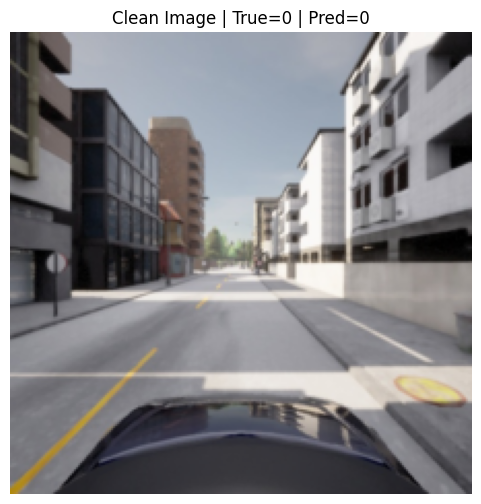

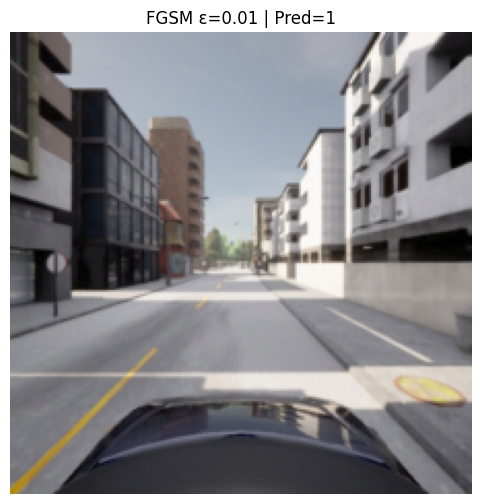


----------------------------------------------------------------------
Example 2
Frame: 100
True label: 1
Clean prediction: 1
Clean P(positive): 0.9998
Adversarial prediction: 0
Adversarial P(positive): 0.4002
Maximum perturbation: 0.010000


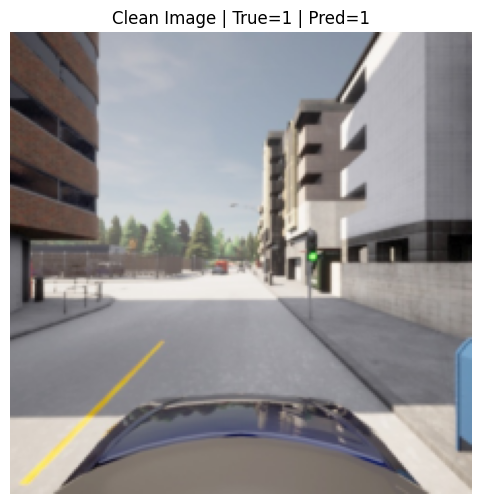

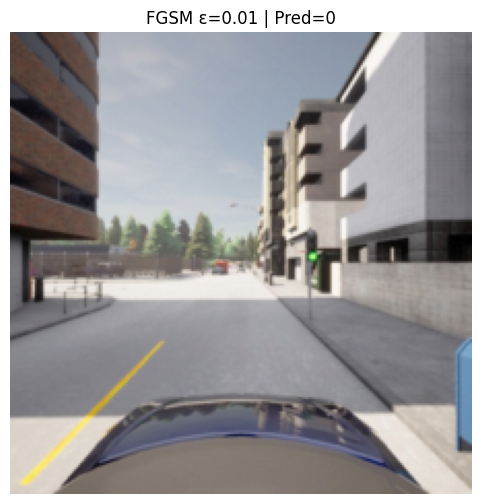


----------------------------------------------------------------------
Example 3
Frame: 110
True label: 1
Clean prediction: 1
Clean P(positive): 0.9994
Adversarial prediction: 0
Adversarial P(positive): 0.2614
Maximum perturbation: 0.010000


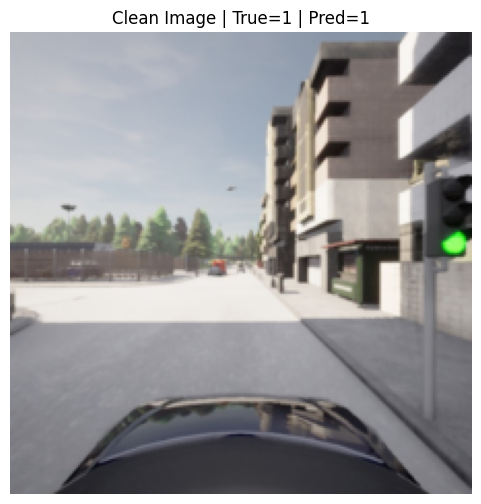

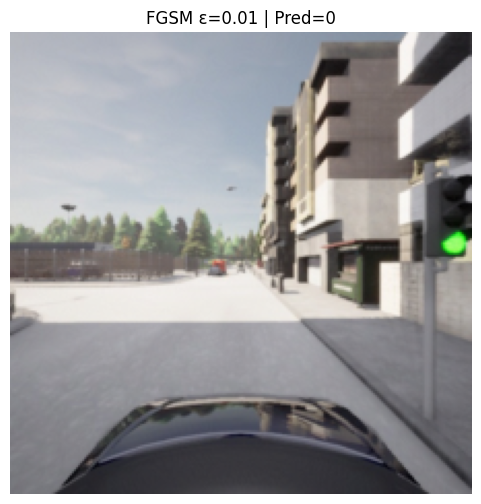


CELL 7 COMPLETE


In [8]:
# ============================================================
# EXERCISE 8.4 - FGSM VISUALIZATION
# CELL 7
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


print("=" * 70)
print("EXERCISE 8.4 - FGSM ADVERSARIAL VISUALIZATION")
print("=" * 70)


# ============================================================
# SELECT MODEL
# ============================================================

VIS_MODEL_NAME = "Traffic Light"

VIS_EPSILON = 0.01

model = models[
    VIS_MODEL_NAME
]

model.eval()


# ============================================================
# GET ONE BATCH
# ============================================================

images, labels, frames = next(
    iter(
        dataloaders[
            VIS_MODEL_NAME
        ]
    )
)

images = images.to(device)
labels = labels.to(device)


# ============================================================
# GENERATE ADVERSARIAL EXAMPLES
# ============================================================

adv_images, attack_loss, _ = fgsm_attack(
    model=model,
    images=images,
    labels=labels,
    epsilon=VIS_EPSILON
)


# ============================================================
# GET CLEAN PREDICTIONS
# ============================================================

with torch.no_grad():

    clean_logits = model(
        images
    )

    clean_probs = torch.softmax(
        clean_logits,
        dim=1
    )

    clean_predictions = (
        clean_probs[:, 1] >= 0.5
    ).long()


# ============================================================
# GET ADVERSARIAL PREDICTIONS
# ============================================================

with torch.no_grad():

    adv_logits = model(
        adv_images
    )

    adv_probs = torch.softmax(
        adv_logits,
        dim=1
    )

    adv_predictions = (
        adv_probs[:, 1] >= 0.5
    ).long()


# ============================================================
# FIND SAMPLES WHERE PREDICTION CHANGED
# ============================================================

changed_indices = torch.where(
    clean_predictions
    !=
    adv_predictions
)[0]


print("\n" + "-" * 70)
print("ATTACK VISUALIZATION")
print("-" * 70)

print(
    "Model:",
    VIS_MODEL_NAME
)

print(
    "Epsilon:",
    VIS_EPSILON
)

print(
    "Prediction changes:",
    len(changed_indices)
)


# ============================================================
# HELPER: DENORMALIZE
# ============================================================

mean = torch.tensor(
    [0.485, 0.456, 0.406],
    device=device
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225],
    device=device
).view(3, 1, 1)


def denormalize(image):

    image = (
        image
        *
        std
        +
        mean
    )

    image = torch.clamp(
        image,
        0,
        1
    )

    return image


# ============================================================
# SELECT UP TO 3 EXAMPLES
# ============================================================

num_examples = min(
    3,
    len(changed_indices)
)


if num_examples == 0:

    print(
        "No prediction changes found "
        "in this batch."
    )

else:

    selected = (
        changed_indices[
            :num_examples
        ]
        .cpu()
        .tolist()
    )


    for plot_number, idx in enumerate(
        selected,
        start=1
    ):

        clean_image = denormalize(
            images[idx]
        )

        adv_image = denormalize(
            adv_images[idx]
        )

        perturbation = (
            adv_images[idx]
            -
            images[idx]
        )


        # ----------------------------------------------------
        # Convert for display
        # ----------------------------------------------------

        clean_display = (
            clean_image
            .permute(1, 2, 0)
            .detach()
            .cpu()
            .numpy()
        )

        adv_display = (
            adv_image
            .permute(1, 2, 0)
            .detach()
            .cpu()
            .numpy()
        )


        print("\n" + "-" * 70)

        print(
            f"Example {plot_number}"
        )

        print(
            "Frame:",
            int(frames[idx])
        )

        print(
            "True label:",
            int(labels[idx])
        )

        print(
            "Clean prediction:",
            int(clean_predictions[idx])
        )

        print(
            "Clean P(positive):",
            f"{clean_probs[idx, 1].item():.4f}"
        )

        print(
            "Adversarial prediction:",
            int(adv_predictions[idx])
        )

        print(
            "Adversarial P(positive):",
            f"{adv_probs[idx, 1].item():.4f}"
        )

        print(
            "Maximum perturbation:",
            f"{perturbation.abs().max().item():.6f}"
        )


        # ----------------------------------------------------
        # Plot clean image
        # ----------------------------------------------------

        plt.figure(
            figsize=(6, 6)
        )

        plt.imshow(
            clean_display
        )

        plt.title(
            f"Clean Image | "
            f"True={int(labels[idx])} | "
            f"Pred={int(clean_predictions[idx])}"
        )

        plt.axis(
            "off"
        )

        plt.show()


        # ----------------------------------------------------
        # Plot adversarial image
        # ----------------------------------------------------

        plt.figure(
            figsize=(6, 6)
        )

        plt.imshow(
            adv_display
        )

        plt.title(
            f"FGSM ε={VIS_EPSILON} | "
            f"Pred={int(adv_predictions[idx])}"
        )

        plt.axis(
            "off"
        )

        plt.show()


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("CELL 7 COMPLETE")
print("=" * 70)

EXERCISE 8.5 - RECALL DEGRADATION ANALYSIS

RECALL DEGRADATION


,Model,Epsilon,Clean Recall (%),Adversarial Recall (%),Recall Drop (pp)
0,Pedestrian,0.01,10.481586,0.000000,10.481586
1,Pedestrian,0.05,10.481586,0.000000,10.481586
2,Pedestrian,0.10,10.481586,0.000000,10.481586
3,Traffic Light,0.01,97.755418,22.445820,75.309598
4,Traffic Light,0.05,97.755418,0.038700,97.716718
5,Traffic Light,0.10,97.755418,0.000000,97.755418
6,Vehicle,0.01,93.185185,51.518519,41.666667
7,Vehicle,0.05,93.185185,23.222222,69.962963
8,Vehicle,0.10,93.185185,28.555556,64.629630


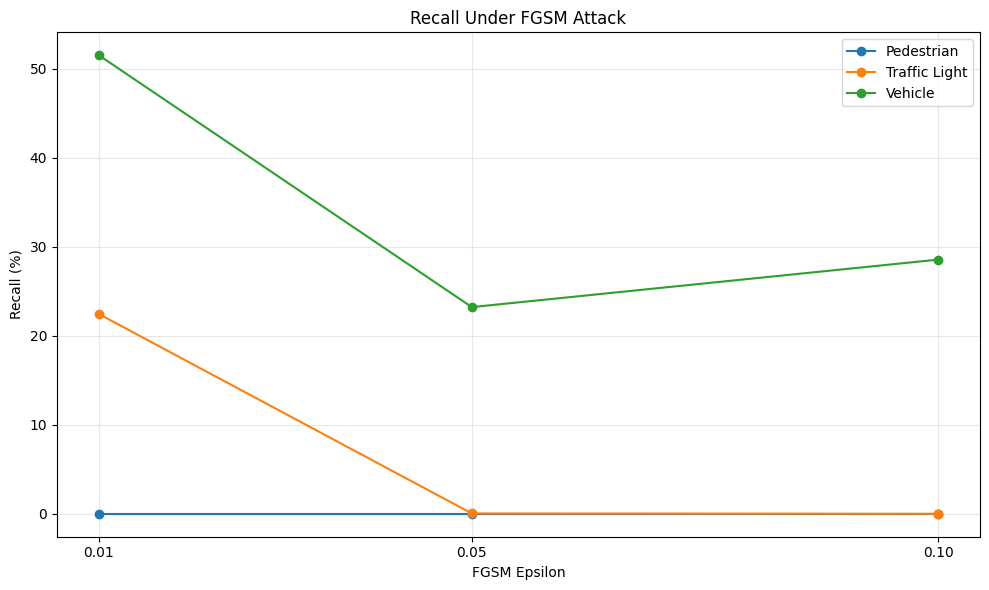

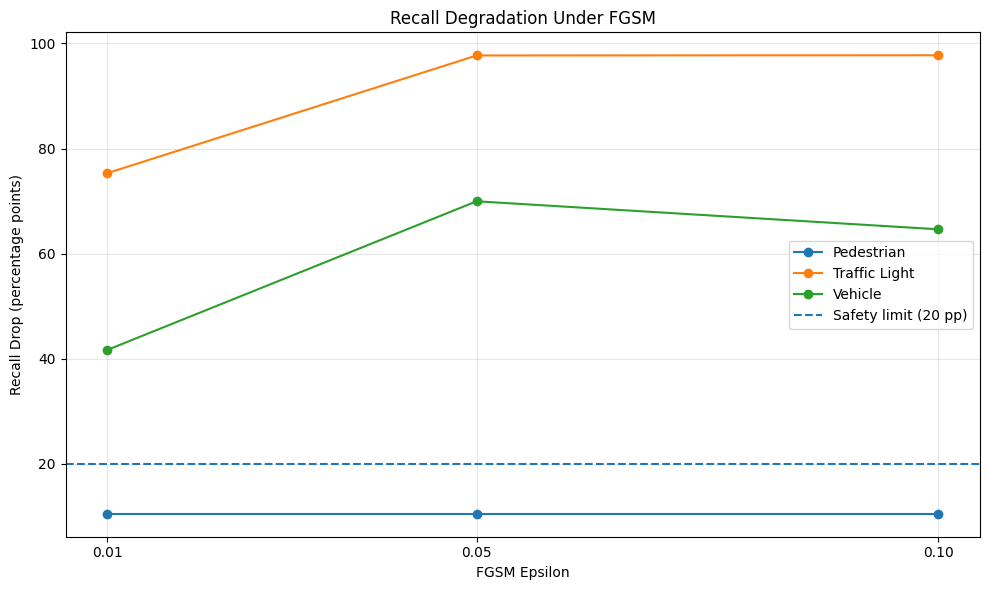


SAFETY REQUIREMENT ANALYSIS
Pedestrian      | Maximum recall drop <= 0.05: 10.48 pp | PASS
Traffic Light   | Maximum recall drop <= 0.05: 97.72 pp | FAIL
Vehicle         | Maximum recall drop <= 0.05: 69.96 pp | FAIL

----------------------------------------------------------------------
WORST ADVERSARIAL RESULT
----------------------------------------------------------------------
Model              : Traffic Light
Epsilon            : 0.1
Clean Recall       : 97.76%
Adversarial Recall : 0.00%
Recall Drop        : 97.76 pp

RECALL DEGRADATION ANALYSIS COMPLETE
Analysis saved to: E:\ML_Safety\adversarial_results\recall_degradation_analysis.csv

CELL 8 COMPLETE


In [9]:
# ============================================================
# EXERCISE 8.5 - RECALL DEGRADATION ANALYSIS
# CELL 8
# ============================================================

print("=" * 70)
print("EXERCISE 8.5 - RECALL DEGRADATION ANALYSIS")
print("=" * 70)


# ============================================================
# PREPARE ANALYSIS DATA
# ============================================================

recall_analysis = fgsm_results_df[
    [
        "Model",
        "Epsilon",
        "Clean Recall",
        "Recall",
        "Recall Drop"
    ]
].copy()


recall_analysis[
    "Clean Recall (%)"
] = (
    recall_analysis[
        "Clean Recall"
    ]
    * 100
)


recall_analysis[
    "Adversarial Recall (%)"
] = (
    recall_analysis[
        "Recall"
    ]
    * 100
)


recall_analysis[
    "Recall Drop (pp)"
] = (
    recall_analysis[
        "Recall Drop"
    ]
    * 100
)


# ============================================================
# DISPLAY
# ============================================================

print("\n" + "=" * 70)
print("RECALL DEGRADATION")
print("=" * 70)

display(
    recall_analysis[
        [
            "Model",
            "Epsilon",
            "Clean Recall (%)",
            "Adversarial Recall (%)",
            "Recall Drop (pp)"
        ]
    ]
)


# ============================================================
# PLOT ADVERSARIAL RECALL
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for model_name in models:

    model_data = recall_analysis[
        recall_analysis[
            "Model"
        ] == model_name
    ]

    plt.plot(
        model_data["Epsilon"],
        model_data["Adversarial Recall (%)"],
        marker="o",
        label=model_name
    )


plt.xlabel(
    "FGSM Epsilon"
)

plt.ylabel(
    "Recall (%)"
)

plt.title(
    "Recall Under FGSM Attack"
)

plt.xticks(
    EPSILONS
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT RECALL DROP
# ============================================================

plt.figure(
    figsize=(10, 6)
)

for model_name in models:

    model_data = recall_analysis[
        recall_analysis[
            "Model"
        ] == model_name
    ]

    plt.plot(
        model_data["Epsilon"],
        model_data["Recall Drop (pp)"],
        marker="o",
        label=model_name
    )


# ------------------------------------------------------------
# Safety threshold
# ------------------------------------------------------------

plt.axhline(
    20,
    linestyle="--",
    label="Safety limit (20 pp)"
)


plt.xlabel(
    "FGSM Epsilon"
)

plt.ylabel(
    "Recall Drop (percentage points)"
)

plt.title(
    "Recall Degradation Under FGSM"
)

plt.xticks(
    EPSILONS
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# SAFETY STATUS
# ============================================================

print("\n" + "=" * 70)
print("SAFETY REQUIREMENT ANALYSIS")
print("=" * 70)

for model_name in models:

    model_data = recall_analysis[
        (
            recall_analysis["Model"]
            == model_name
        )
        &
        (
            recall_analysis["Epsilon"]
            <= 0.05
        )
    ]

    maximum_drop = model_data[
        "Recall Drop (pp)"
    ].max()

    if maximum_drop <= 20:

        status = "PASS"

    else:

        status = "FAIL"


    print(
        f"{model_name:15s} | "
        f"Maximum recall drop <= 0.05: "
        f"{maximum_drop:.2f} pp | "
        f"{status}"
    )


# ============================================================
# WORST RESULT
# ============================================================

worst_attack = recall_analysis.loc[
    recall_analysis[
        "Recall Drop"
    ].idxmax()
]


print("\n" + "-" * 70)
print("WORST ADVERSARIAL RESULT")
print("-" * 70)

print(
    f"Model              : "
    f"{worst_attack['Model']}"
)

print(
    f"Epsilon            : "
    f"{worst_attack['Epsilon']}"
)

print(
    f"Clean Recall       : "
    f"{worst_attack['Clean Recall (%)']:.2f}%"
)

print(
    f"Adversarial Recall : "
    f"{worst_attack['Adversarial Recall (%)']:.2f}%"
)

print(
    f"Recall Drop        : "
    f"{worst_attack['Recall Drop (pp)']:.2f} pp"
)


# ============================================================
# SAVE ANALYSIS
# ============================================================

recall_analysis_path = os.path.join(
    OUTPUT_DIR,
    "recall_degradation_analysis.csv"
)

recall_analysis.to_csv(
    recall_analysis_path,
    index=False
)


print("\n" + "=" * 70)
print("RECALL DEGRADATION ANALYSIS COMPLETE")
print("=" * 70)

print(
    "Analysis saved to:",
    recall_analysis_path
)

print("\nCELL 8 COMPLETE")
print("=" * 70)

In [10]:
# ============================================================
# EXERCISE 8.5 - FINAL FGSM SAFETY ASSESSMENT
# CELL 9
# ============================================================

print("=" * 70)
print("EXERCISE 8.5 - FINAL FGSM SAFETY ASSESSMENT")
print("=" * 70)


# ============================================================
# SAFETY THRESHOLD
# ============================================================

SAFETY_THRESHOLD_PP = 20.0

# Only epsilons required by the safety specification
SAFETY_EPSILONS = [0.01, 0.05]


# ============================================================
# FILTER REQUIRED RESULTS
# ============================================================

safety_df = recall_analysis[
    recall_analysis["Epsilon"].isin(
        SAFETY_EPSILONS
    )
].copy()


# ============================================================
# SAFETY STATUS
# ============================================================

safety_summary = []

for model_name in models:

    model_data = safety_df[
        safety_df["Model"] == model_name
    ]

    maximum_drop = model_data[
        "Recall Drop (pp)"
    ].max()

    clean_recall = model_data[
        "Clean Recall (%)"
    ].iloc[0]

    if maximum_drop <= SAFETY_THRESHOLD_PP:
        status = "PASS"
    else:
        status = "FAIL"

    safety_summary.append([
        model_name,
        clean_recall,
        maximum_drop,
        SAFETY_THRESHOLD_PP,
        status
    ])


safety_summary_df = pd.DataFrame(
    safety_summary,
    columns=[
        "Model",
        "Clean Recall (%)",
        "Maximum Recall Drop (pp)",
        "Safety Limit (pp)",
        "Status"
    ]
)


# ============================================================
# DISPLAY SAFETY TABLE
# ============================================================

print("\n" + "=" * 70)
print("FGSM SAFETY REQUIREMENT")
print("=" * 70)

print(
    "\nRequirement:"
)

print(
    "All classifiers must maintain recall drop "
    "<= 20 percentage points under FGSM "
    "for epsilon <= 0.05."
)

display(
    safety_summary_df
)


# ============================================================
# INDIVIDUAL EPSILON RESULTS
# ============================================================

print("\n" + "=" * 70)
print("DETAILED SAFETY RESULTS")
print("=" * 70)

display(
    safety_df[
        [
            "Model",
            "Epsilon",
            "Clean Recall (%)",
            "Adversarial Recall (%)",
            "Recall Drop (pp)"
        ]
    ]
)


# ============================================================
# OVERALL SYSTEM STATUS
# ============================================================

all_models_pass = (
    safety_summary_df["Status"] == "PASS"
).all()


print("\n" + "=" * 70)
print("OVERALL SAFETY STATUS")
print("=" * 70)


if all_models_pass:

    print(
        "SYSTEM STATUS: PASS"
    )

    print(
        "All classifiers satisfy the FGSM "
        "recall-drop requirement."
    )

else:

    print(
        "SYSTEM STATUS: FAIL"
    )

    failed_models = safety_summary_df[
        safety_summary_df["Status"] == "FAIL"
    ]["Model"].tolist()

    print(
        "Models failing the requirement:"
    )

    for model_name in failed_models:

        print(
            f"  - {model_name}"
        )


# ============================================================
# MOST VULNERABLE MODEL
# ============================================================

most_vulnerable = safety_summary_df.loc[
    safety_summary_df[
        "Maximum Recall Drop (pp)"
    ].idxmax()
]


print("\n" + "-" * 70)
print("MOST VULNERABLE MODEL")
print("-" * 70)

print(
    f"Model              : "
    f"{most_vulnerable['Model']}"
)

print(
    f"Clean Recall       : "
    f"{most_vulnerable['Clean Recall (%)']:.2f}%"
)

print(
    f"Maximum Recall Drop: "
    f"{most_vulnerable['Maximum Recall Drop (pp)']:.2f} pp"
)

print(
    f"Safety Limit       : "
    f"{SAFETY_THRESHOLD_PP:.2f} pp"
)

print(
    f"Status              : "
    f"{most_vulnerable['Status']}"
)


# ============================================================
# PEDestrian INTERPRETATION
# ============================================================

pedestrian_row = safety_summary_df[
    safety_summary_df["Model"] == "Pedestrian"
].iloc[0]


print("\n" + "-" * 70)
print("PEDESTRIAN MODEL NOTE")
print("-" * 70)

print(
    f"Pedestrian satisfies the recall-drop "
    f"threshold with a maximum drop of "
    f"{pedestrian_row['Maximum Recall Drop (pp)']:.2f} pp."
)

print(
    f"However, its clean baseline recall is only "
    f"{pedestrian_row['Clean Recall (%)']:.2f}%, "
    "indicating poor baseline detection performance."
)


# ============================================================
# SAVE FINAL SAFETY ASSESSMENT
# ============================================================

safety_path = os.path.join(
    OUTPUT_DIR,
    "fgsm_final_safety_assessment.csv"
)

safety_summary_df.to_csv(
    safety_path,
    index=False
)


# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n" + "=" * 70)
print("FINAL FGSM SAFETY ASSESSMENT COMPLETE")
print("=" * 70)

print(
    "Assessment saved to:",
    safety_path
)

print("\nCELL 9 COMPLETE")
print("=" * 70)

EXERCISE 8.5 - FINAL FGSM SAFETY ASSESSMENT

FGSM SAFETY REQUIREMENT

Requirement:
All classifiers must maintain recall drop <= 20 percentage points under FGSM for epsilon <= 0.05.


,Model,Clean Recall (%),Maximum Recall Drop (pp),Safety Limit (pp),Status
0,Pedestrian,10.481586,10.481586,20.0,PASS
1,Traffic Light,97.755418,97.716718,20.0,FAIL
2,Vehicle,93.185185,69.962963,20.0,FAIL



DETAILED SAFETY RESULTS


,Model,Epsilon,Clean Recall (%),Adversarial Recall (%),Recall Drop (pp)
0,Pedestrian,0.01,10.481586,0.000000,10.481586
1,Pedestrian,0.05,10.481586,0.000000,10.481586
3,Traffic Light,0.01,97.755418,22.445820,75.309598
4,Traffic Light,0.05,97.755418,0.038700,97.716718
6,Vehicle,0.01,93.185185,51.518519,41.666667
7,Vehicle,0.05,93.185185,23.222222,69.962963



OVERALL SAFETY STATUS
SYSTEM STATUS: FAIL
Models failing the requirement:
  - Traffic Light
  - Vehicle

----------------------------------------------------------------------
MOST VULNERABLE MODEL
----------------------------------------------------------------------
Model              : Traffic Light
Clean Recall       : 97.76%
Maximum Recall Drop: 97.72 pp
Safety Limit       : 20.00 pp
Status              : FAIL

----------------------------------------------------------------------
PEDESTRIAN MODEL NOTE
----------------------------------------------------------------------
Pedestrian satisfies the recall-drop threshold with a maximum drop of 10.48 pp.
However, its clean baseline recall is only 10.48%, indicating poor baseline detection performance.

FINAL FGSM SAFETY ASSESSMENT COMPLETE
Assessment saved to: E:\ML_Safety\adversarial_results\fgsm_final_safety_assessment.csv

CELL 9 COMPLETE
